In [ ]:
!pip install pvlib --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.3/19.3 MB 47.2 MB/s eta 0:00:00


In [1]:

!pip install pvlib --quiet


import pandas as pd
import numpy as np
import pvlib
from pvlib.location import Location


#location & time

latitude, longitude = 6.9, 79.9  #Sri Lanka
location = Location(latitude, longitude)

# Simulate 30 days with 5-minute intervals
num_days = 30
start_date = '2026-01-01'
end_date = pd.to_datetime(start_date) + pd.Timedelta(days=num_days-1)
times = pd.date_range(start=start_date, end=end_date + pd.Timedelta(hours=18), freq='5min')

#Clear-sky irradiance
clearsky = location.get_clearsky(times)
irradiance_clear = clearsky['ghi'].values  # Global horizontal irradiance

# Panel & system setup
system = pvlib.pvsystem.PVSystem(
    surface_tilt=30,
    surface_azimuth=180,
    module_parameters={'pdc0': 250, 'gamma_pdc': -0.004},
    inverter_parameters={'pdc0': 250}
)

# Simulate ambient temp and panel temp
ambient_temp = 30 + 5*np.sin(np.linspace(0, 2*np.pi*num_days, len(times)))  # daily variation
panel_temp = ambient_temp + irradiance_clear*0.05  # simple linear model


#Add random shadows
shadow_factor = np.ones(len(times))
np.random.seed(42)

for single_day in pd.date_range(start=start_date, end=end_date):
    # Daylight indices for this day
    day_mask = (times.date == single_day.date()) & (irradiance_clear > 0)
    day_indices = np.where(day_mask)[0]
    if len(day_indices) == 0:
        continue

    # Random number of shadow events per day (1-3)
    num_shadows = np.random.randint(1, 4)
    for _ in range(num_shadows):
        start_idx = np.random.choice(day_indices)
        duration = np.random.randint(6, 18)  # 30-90 minutes
        duration = min(duration, len(day_indices) - (start_idx - day_indices[0]))
        factor = np.random.uniform(0.4, 0.8)  # 40%-80% irradiance
        shadow_factor[start_idx:start_idx+duration] = factor

# Apply shadows
irradiance_shaded = irradiance_clear * shadow_factor

#Compute DC power
dc_power = system.pvwatts_dc(irradiance_shaded, temp_cell=panel_temp)
dc_power_clear = system.pvwatts_dc(irradiance_clear, temp_cell=panel_temp)

# Shadow energy loss
shadow_effect = dc_power_clear - dc_power

#Create shadow label
shadow_label = np.where(shadow_factor < 1, 1, 0)  # 1 = shaded, 0 = clear

#Create final dataset

dataset = pd.DataFrame({
    'timestamp': times,
    'irradiance': irradiance_shaded,
    'panel_temp': panel_temp,
    'dc_power': dc_power,
    'dc_power_clear': dc_power_clear,
    'shadow_effect': shadow_effect,
    'shadow_factor': shadow_factor,
    'shadow_label': shadow_label
})

#Save dataset
dataset.to_csv('simulated_pv_shadow_forecast_data.csv', index=False)
from google.colab import files
files.download('simulated_pv_shadow_forecast_data.csv')
print("Dataset saved as 'simulated_pv_shadow_forecast_data.csv'")
dataset.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 62.7 MB/s eta 0:00:00


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Dataset saved as 'simulated_pv_shadow_forecast_data.csv'


,timestamp,irradiance,panel_temp,dc_power,dc_power_clear,shadow_effect,shadow_factor,shadow_label
0,2026-01-01 00:00:00,0.0,30.000000,0.0,0.0,0.0,1.0,0
1,2026-01-01 00:05:00,0.0,30.109991,0.0,0.0,0.0,1.0,0
2,2026-01-01 00:10:00,0.0,30.219929,0.0,0.0,0.0,1.0,0
3,2026-01-01 00:15:00,0.0,30.329760,0.0,0.0,0.0,1.0,0
4,2026-01-01 00:20:00,0.0,30.439431,0.0,0.0,0.0,1.0,0


In [3]:
import pandas as pd
import numpy as np

# Load simulated dataset
df = pd.read_csv('simulated_pv_shadow_forecast_data.csv', parse_dates=['timestamp'])
df.head()


,timestamp,irradiance,panel_temp,dc_power,dc_power_clear,shadow_effect,shadow_factor,shadow_label
0,2026-01-01 00:00:00,0.0,30.000000,0.0,0.0,0.0,1.0,0
1,2026-01-01 00:05:00,0.0,30.109991,0.0,0.0,0.0,1.0,0
2,2026-01-01 00:10:00,0.0,30.219929,0.0,0.0,0.0,1.0,0
3,2026-01-01 00:15:00,0.0,30.329760,0.0,0.0,0.0,1.0,0
4,2026-01-01 00:20:00,0.0,30.439431,0.0,0.0,0.0,1.0,0


In [4]:
#Feature Preparation
import numpy as np
import pandas as pd

# Load your existing dataset
df = pd.read_csv('simulated_pv_shadow_forecast_data.csv', parse_dates=['timestamp'])

# Features and target
features = ['irradiance', 'panel_temp', 'dc_power_clear']
target = 'shadow_effect'
window_size = 12  # past 1 hour (5-min intervals)

X, y = [], []
for i in range(window_size, len(df)):
    X.append(df[features].iloc[i-window_size:i].values)
    y.append(df[target].iloc[i])

X = np.array(X)
y = np.array(y)

# Train-test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]



In [5]:
#Build LSTM Model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, input_shape=(window_size, len(features))),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')  # Regression output for shadow loss
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=64
)




Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 140.8424 - mae: 3.1270 - val_loss: 162.3484 - val_mae: 3.9252
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 124.1457 - mae: 3.3809 - val_loss: 93.7509 - val_mae: 2.6564
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 53.7092 - mae: 2.0035 - val_loss: 56.0520 - val_mae: 2.2918
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 41.0102 - mae: 1.6847 - val_loss: 44.6112 - val_mae: 1.9503
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 47.6510 - mae: 1.7081 - val_loss: 40.1856 - val_mae: 1.3743
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 34.2597 - mae: 1.5344 - val_loss: 42.1160 - val_mae: 1.6230
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 43.1395 - mae: 1.5892 - val_loss: 38.8084 - val_mae: 1.3408
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 36.8648 - mae: 1.4702 - val_loss: 36.5921 - val_mae: 1.4467
Epoch 9/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 13m

In [6]:
# Predict shadow loss
y_pred_shadow = model.predict(X_test)

# Compute predicted power with shadow
dc_power_clear_test = X_test[:, -1, 2]  # last timestep of dc_power_clear in sequence
predicted_power_with_shadow = dc_power_clear_test - y_pred_shadow.flatten()

# Actual power with shadow
actual_power_with_shadow = dc_power_clear_test - y_test

# Handle nighttime: power is zero when clear-sky DC is zero
daylight_mask = dc_power_clear_test > 0
predicted_power_with_shadow[~daylight_mask] = 0
actual_power_with_shadow[~daylight_mask] = 0


54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [8]:

# 2. Calculate Regression Metrics
mae = mean_absolute_error(y_test, y_pred_shadow)
mse = mean_squared_error(y_test, y_pred_shadow)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_shadow)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared Score (R²): {r2:.4f}")

Mean Absolute Error (MAE): 1.3783
Root Mean Squared Error (RMSE): 6.0994
R-squared Score (R²): 0.8059


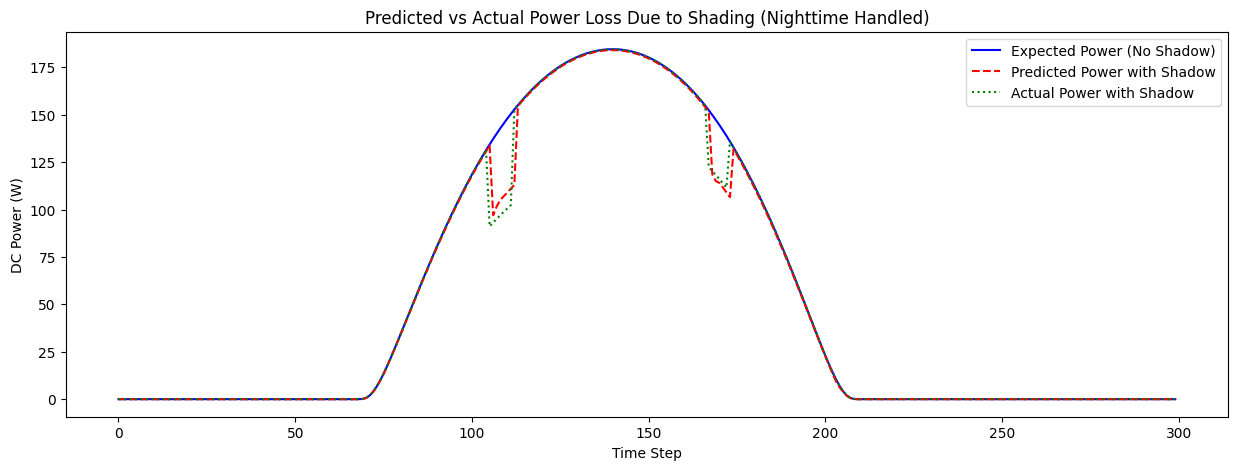

In [9]:
import matplotlib.pyplot as plt

n_points = 300  # number of points to visualize
plt.figure(figsize=(15,5))

plt.plot(dc_power_clear_test[:n_points], label='Expected Power (No Shadow)', color='blue')
plt.plot(predicted_power_with_shadow[:n_points], label='Predicted Power with Shadow', color='red', linestyle='--')
plt.plot(actual_power_with_shadow[:n_points], label='Actual Power with Shadow', color='green', linestyle=':')
plt.xlabel('Time Step')
plt.ylabel('DC Power (W)')
plt.title('Predicted vs Actual Power Loss Due to Shading (Nighttime Handled)')
plt.legend()
plt.show()



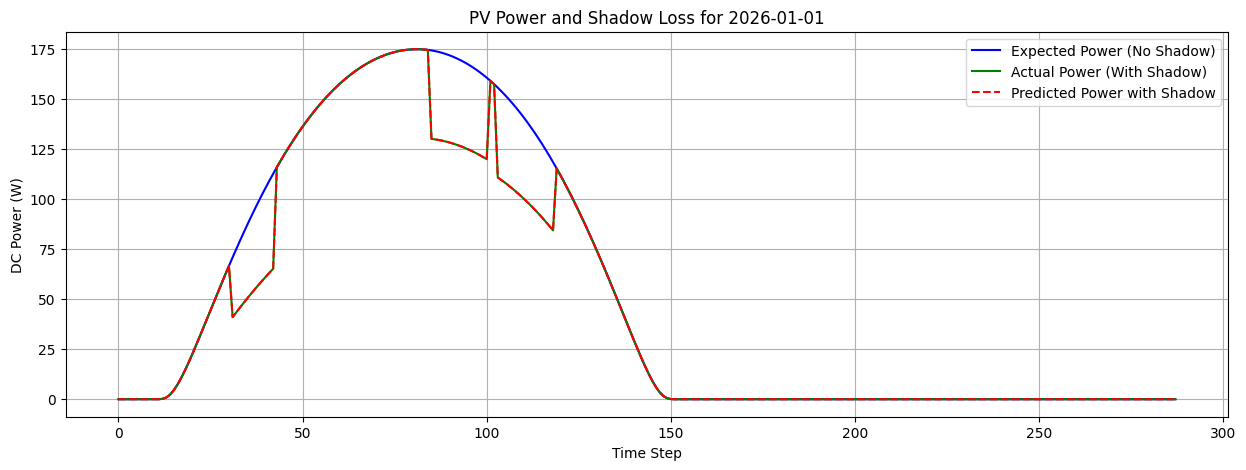

In [10]:
# Select a single day
day_to_plot = pd.to_datetime('2026-01-01')
mask_day = df['timestamp'].dt.date == day_to_plot.date()
df_day = df.loc[mask_day]

plt.figure(figsize=(15,5))
plt.plot(df_day['dc_power_clear'], label='Expected Power (No Shadow)', color='blue')
plt.plot(df_day['dc_power'], label='Actual Power (With Shadow)', color='green')
plt.plot(df_day['dc_power_clear'] - df_day['shadow_effect'],
         label='Predicted Power with Shadow', color='red', linestyle='--')
plt.xlabel('Time Step')
plt.ylabel('DC Power (W)')
plt.title(f'PV Power and Shadow Loss for {day_to_plot.date()}')
plt.legend()
plt.grid(True)
plt.show()


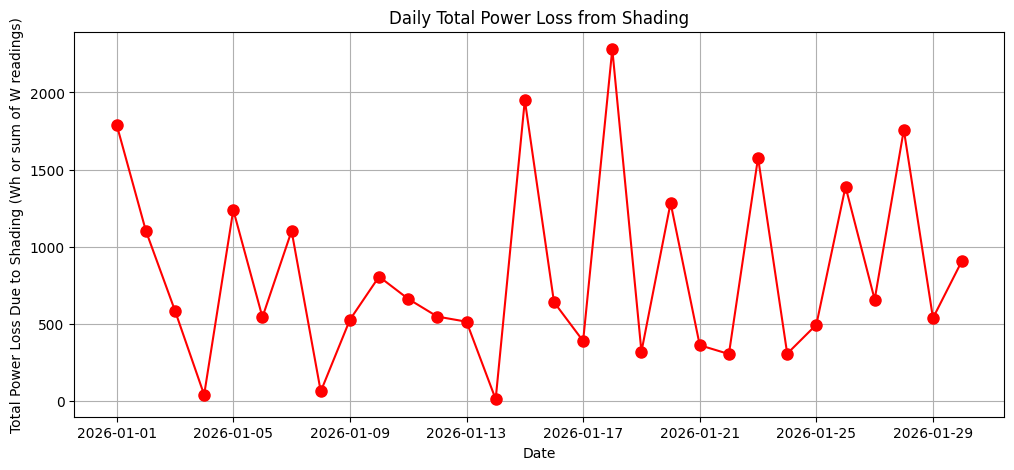

In [11]:

# Create date column
df['date'] = df['timestamp'].dt.date

# Sum shadow effect per day
daily_loss = df.groupby('date')['shadow_effect'].sum()

# Plot daily total power loss with points
plt.figure(figsize=(12,5))
plt.plot(daily_loss.index, daily_loss.values, marker='o', linestyle='-', color='red', markersize=8)
plt.xlabel('Date')
plt.ylabel('Total Power Loss Due to Shading (Wh or sum of W readings)')
plt.title('Daily Total Power Loss from Shading')
plt.grid(True)
plt.show()


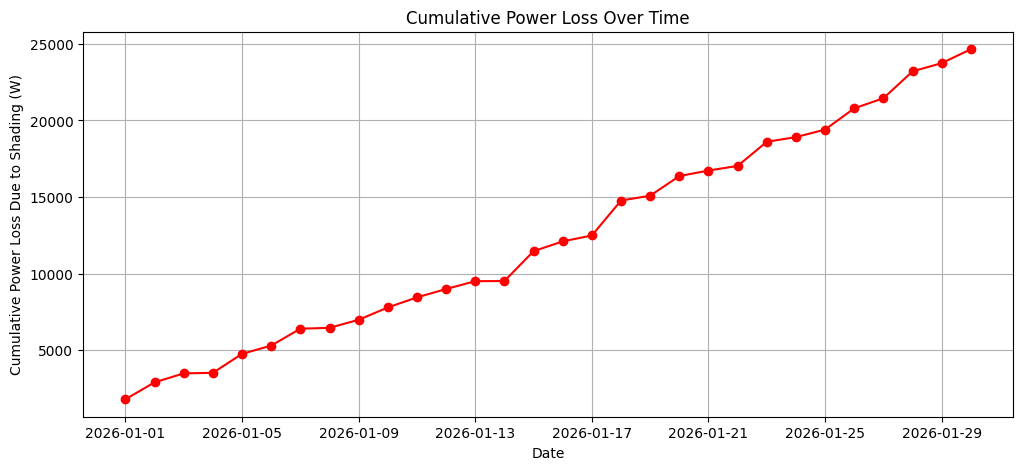

In [12]:
import matplotlib.pyplot as plt

# Daily total power loss (already computed)
daily_loss = df.groupby('date')['shadow_effect'].sum()

# Compute cumulative loss
cumulative_loss = daily_loss.cumsum()

# Plot
plt.figure(figsize=(12,5))
plt.plot(cumulative_loss.index, cumulative_loss.values, marker='o', linestyle='-', color='red')
plt.xlabel('Date')
plt.ylabel('Cumulative Power Loss Due to Shading (W)')
plt.title('Cumulative Power Loss Over Time')
plt.grid(True)
plt.show()


In [13]:
# Daily total power loss
daily_loss = df.groupby('date')['shadow_effect'].sum()

# Basic statistics
mean_loss = daily_loss.mean()
max_loss = daily_loss.max()
min_loss = daily_loss.min()
std_loss = daily_loss.std()
print(daily_loss.head(29))

print("=== Daily Total Power Loss Statistics ===")
print(f"Mean daily loss: {mean_loss:.2f} W")
print(f"Max daily loss: {max_loss:.2f} W")
print(f"Min daily loss: {min_loss:.2f} W")
print(f"Standard deviation: {std_loss:.2f} W")

# Optional: Top 3 days with highest loss
top_days = daily_loss.sort_values(ascending=False).head(3)
print("\nTop 3 worst loss days:")
print(top_days)

date
2026-01-01    1790.628130
2026-01-02    1102.948965
2026-01-03     583.772033
2026-01-04      37.428224
2026-01-05    1237.511212
2026-01-06     541.434883
2026-01-07    1100.946789
2026-01-08      59.101386
2026-01-09     524.673563
2026-01-10     804.753882
2026-01-11     660.120331
2026-01-12     545.272080
2026-01-13     511.998777
2026-01-14       8.776797
2026-01-15    1950.606347
2026-01-16     639.270543
2026-01-17     386.558895
2026-01-18    2280.908311
2026-01-19     317.306068
2026-01-20    1283.093633
2026-01-21     359.432119
2026-01-22     302.068193
2026-01-23    1576.864471
2026-01-24     304.529867
2026-01-25     492.835100
2026-01-26    1388.651923
2026-01-27     655.968720
2026-01-28    1757.643245
2026-01-29     535.747311
Name: shadow_effect, dtype: float64
=== Daily Total Power Loss Statistics ===
Mean daily loss: 821.67 W
Max daily loss: 2280.91 W
Min daily loss: 8.78 W
Standard deviation: 598.44 W

Top 3 worst loss days:
date
2026-01-18    2280.908311
2026

In [14]:
import pandas as pd

# 1. Get predictions and timestamps for the test set
y_pred = model.predict(X_test).flatten()
# Get the corresponding timestamps for the test set
test_timestamps = df['timestamp'].iloc[window_size:].iloc[split:].values
# Get clear sky power to calculate relative error
test_clear_power = df['dc_power_clear'].iloc[window_size:].iloc[split:].values

# 2. Create the Results DataFrame
results_df = pd.DataFrame({
    'Timestamp': test_timestamps,
    'Actual_Loss_W': y_test,
    'Predicted_Loss_W': y_pred,
    'Abs_Error_W': np.abs(y_test - y_pred)
})

# 3. Add a Percentage Error (relative to clear sky potential)
results_df['Error_Percentage'] = (results_df['Abs_Error_W'] / (test_clear_power + 1e-9)) * 100

# 4. Filter for only "Shaded" events to see how it performs when it matters
# (Ignoring clear periods where loss is 0)
shadow_results = results_df[results_df['Actual_Loss_W'] > 1.0].head(10)

print("LSTM Shadow Prediction Results (Sample of Shaded Events):")
print(shadow_results.to_string(index=False))

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
LSTM Shadow Prediction Results (Sample of Shaded Events):
          Timestamp  Actual_Loss_W  Predicted_Loss_W  Abs_Error_W  Error_Percentage
2026-01-25 04:10:00      43.248378          0.552930    42.695448         31.106332
2026-01-25 04:15:00      44.135067         40.280918     3.854149          2.751578
2026-01-25 04:20:00      44.993261         38.449909     6.543352          4.582367
2026-01-25 04:25:00      45.823044         37.752132     8.070912          5.549779
2026-01-25 04:30:00      46.624515         38.439880     8.184635          5.531234
2026-01-25 04:35:00      47.397789         38.958019     8.439770          5.610603
2026-01-25 04:40:00      48.142991         39.412373     8.730618          5.714115
2026-01-25 09:20:00      30.116132          0.798649    29.317482         19.557604
2026-01-25 09:25:00      29.594538         31.332928     1.738390          1.180114
2026-01-25 09:30:00      29.052849         32.283504     3.2306